# S2V-DQN EDS (Fixed) — Erdős-Rényi Graphs

## 1. Install

In [1]:
!pip install torch torch_geometric networkx numpy pandas scikit-learn tqdm --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports & Config

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random, time
from collections import deque
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEAT_DIM      = 12
HIDDEN        = 64
K_HOPS        = 4
BATCH_SIZE    = 64
GAMMA         = 0.99
EPS_START     = 1.0
EPS_END       = 0.05
EPS_DECAY     = 0.998      
TARGET_UPDATE = 150
N_EPISODES    = 6000
LR            = 1e-4       
N_TRAIN       = 1000
N_TEST        = 200

print(f"Device : {DEVICE}")

Device : cpu


## 3. Generator — Erdős-Rényi

In [3]:
def make_graph(seed):
    rng=random.Random(seed)
    n=rng.randint(15,40); p=rng.uniform(0.2,0.5)
    for attempt in range(50):
        G=nx.erdos_renyi_graph(n,p,seed=seed+attempt)
        if nx.is_connected(G) and G.number_of_edges()>0:
            return nx.convert_node_labels_to_integers(G)
    return nx.convert_node_labels_to_integers(
               nx.erdos_renyi_graph(n,0.6,seed=seed))

G0=make_graph(0)
print(f'Sample ER: {G0.number_of_nodes()} nodes, {G0.number_of_edges()} edges')

Sample ER: 27 nodes, 148 edges


## 4. Line Graph & Coverage Helpers

In [ ]:
def build_covers(G, edges):
    eidx = {}
    for i,(u,v) in enumerate(edges): eidx[(u,v)]=i; eidx[(v,u)]=i
    covers = [set() for _ in range(len(edges))]
    for i,(u,v) in enumerate(edges):
        for w in G.neighbors(u):
            j=eidx.get((u,w),eidx.get((w,u),-1))
            if j>=0: covers[i].add(j)
        for w in G.neighbors(v):
            j=eidx.get((v,w),eidx.get((w,v),-1))
            if j>=0: covers[i].add(j)
        covers[i].add(i)
    return covers

def build_line_graph_adj(G, edges):
    n_e  = len(edges)
    eidx = {}
    for i,(u,v) in enumerate(edges): eidx[(u,v)]=i; eidx[(v,u)]=i
    adj  = np.zeros((n_e, n_e), dtype=np.float32)
    for node in G.nodes():
        inc = list(G.edges(node))
        for a in range(len(inc)):
            for b in range(a+1, len(inc)):
                ei,ej = eidx[inc[a]], eidx[inc[b]]
                if ei!=ej: adj[ei,ej]=1.0; adj[ej,ei]=1.0
    return torch.tensor(adj, dtype=torch.float32, device=DEVICE)

def normalized_adj(adj):
    A   = adj + torch.eye(adj.size(0), device=adj.device)
    D   = A.sum(dim=1).clamp(min=1e-8)
    return (A / D.unsqueeze(1))

def is_valid_eds(covers, selected_idx, n):
    dominated = set()
    for i in selected_idx: dominated |= covers[i]
    return dominated == set(range(n))

print("Line-graph helpers ready.")

Line-graph helpers ready.


## 5. Edge Feature Extraction (12-dim)

In [ ]:
def extract_edge_features(G, edges, seed=0):
    rng  = np.random.default_rng(seed)
    deg  = dict(G.degree()); maxd = max(deg.values()) or 1
    try:    bc = nx.betweenness_centrality(G, normalized=True)
    except: bc = {v:0.0 for v in G}
    try:    ec = nx.eigenvector_centrality_numpy(G)
    except: ec = {v:0.0 for v in G}
    try:    cl = nx.clustering(G)
    except: cl = {v:0.0 for v in G}
    rows = []
    for u,v in edges:
        du,dv = deg[u]/maxd, deg[v]/maxd
        rows.append([du,dv,(du+dv)/2,abs(du-dv),du*dv,
                     min(du,dv)/(max(du,dv)+1e-6),
                     bc[u],bc[v],ec[u],ec[v],cl[u],cl[v]])
    x = np.array(rows, dtype=np.float32)
    x += rng.normal(0, 0.01, x.shape).astype(np.float32)  
    return torch.tensor(x, dtype=torch.float32, device=DEVICE)

print(f"Feature dim: {FEAT_DIM}")

Feature dim: 12


## 6. EDS Environment

In [ ]:
class EDSEnvironment:
    def __init__(self, G, edges, covers):
        self.edges  = edges
        self.covers = covers
        self.n      = len(edges)
        self.reset()

    def reset(self):
        self.selected  = set()
        self.dominated = set()
        self.state_mask = torch.zeros((self.n, 2), dtype=torch.float32, device=DEVICE)
        return self.state_mask.clone()

    def step(self, action):
        prev = len(self.dominated)
        self.selected.add(action)
        self.state_mask[action, 0] = 1.0
        for j in self.covers[action]:
            self.dominated.add(j)
            self.state_mask[j, 1] = 1.0
        newly = len(self.dominated) - prev
        done  = (self.dominated == set(range(self.n)))
        # FIX #1: normalised reward — stays in (-1, +1)
        reward = (newly / self.n) - (1.0 / self.n)
        return self.state_mask.clone(), reward, done

print("EDS environment ready.")

EDS environment ready.


## 7. S2V-DQN Model, Replay Buffer, DQN Update

In [ ]:
class S2V_DQN_EDS(nn.Module):
    def __init__(self, feat_dim=FEAT_DIM, hidden=HIDDEN, K=K_HOPS):
        super().__init__()
        self.K    = K
        self.proj = nn.Linear(feat_dim + 2, hidden)  

        self.W_msg = nn.Linear(hidden, hidden, bias=False)
        self.W_upd = nn.Linear(hidden, hidden, bias=False)
        self.ln    = nn.LayerNorm(hidden)             

        self.q_node  = nn.Linear(hidden, hidden)
        self.q_graph = nn.Linear(hidden, hidden)
        self.q_out   = nn.Linear(hidden, 1)

        # FIX #4: zero-init
        nn.init.zeros_(self.q_out.weight)
        nn.init.zeros_(self.q_out.bias)

    def forward(self, x_feat, state_mask, norm_adj):
        x = torch.cat([x_feat, state_mask], dim=-1)
        h = torch.relu(self.proj(x))
        for _ in range(self.K):
            msg = torch.matmul(norm_adj, self.W_msg(h))
            h   = torch.relu(self.ln(self.W_upd(h) + msg))
        g = h.sum(dim=0, keepdim=True).expand(h.size(0), -1)
        q = self.q_out(torch.relu(self.q_node(h) + self.q_graph(g)))
        return q.squeeze(-1)

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)
    def push(self, t):   self.buf.append(t)
    def sample(self, k): return random.sample(self.buf, k)
    def __len__(self):   return len(self.buf)

def select_action(q_vals, state_mask, epsilon):
    valid = (state_mask[:, 0] == 0).nonzero(as_tuple=True)[0].tolist()
    if random.random() < epsilon:
        return random.choice(valid)
    masked = q_vals.clone()
    masked[state_mask[:, 0] == 1] = -1e9
    return int(torch.argmax(masked).item())

huber = nn.SmoothL1Loss()  

def dqn_update(replay, policy_net, target_net, optimizer):
    if len(replay) < BATCH_SIZE:
        return None
    batch      = replay.sample(BATCH_SIZE)
    loss_total = torch.tensor(0.0, device=DEVICE)
    policy_net.train()
    for (x, adj, state, action, reward, next_state, done) in batch:
        cur_q = policy_net(x, state, adj)[action]
        with torch.no_grad():
            if done:
                target = torch.tensor(reward, dtype=torch.float32, device=DEVICE)
            else:
                nq = target_net(x, next_state, adj)
                nq[next_state[:, 0] == 1] = -1e9
                target = reward + GAMMA * nq.max().clamp(-10, 10)
        loss_total = loss_total + huber(cur_q.unsqueeze(0), target.float().unsqueeze(0))
    loss = loss_total / BATCH_SIZE
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 0.5)   
    optimizer.step()
    return loss.item()

policy_net = S2V_DQN_EDS().to(DEVICE)
target_net = S2V_DQN_EDS().to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
replay    = ReplayBuffer()

print(f"S2V-DQN parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

S2V-DQN parameters: 17,665


## 8. Baseline Algorithms

In [ ]:
def greedy_eds_size(G):
    edges=list(G.edges()); n=len(edges); eidx={}
    for i,(u,v) in enumerate(edges): eidx[(u,v)]=i; eidx[(v,u)]=i
    def cov(i):
        u,v=edges[i]; c=set()
        for nb in list(G.edges(u))+list(G.edges(v)): c.add(eidx[nb])
        return c
    covered,remaining,sel=set(),set(range(n)),[]
    while covered!=set(range(n)):
        best=max(remaining,key=lambda i:len(cov(i)-covered))
        sel.append(best); covered|=cov(best); remaining.discard(best)
    return len(sel)

def two_approx_size(G):
    return len(nx.maximal_matching(G))

print("Baselines ready.")

Baselines ready.


## 9. Generate Dataset — 1000 Train + 200 Test

In [ ]:
def make_sample(G, seed):
    edges  = list(G.edges())
    covers = build_covers(G, edges)
    adj    = normalized_adj(build_line_graph_adj(G, edges))
    x      = extract_edge_features(G, edges, seed=seed)
    return {"G":G,"edges":edges,"covers":covers,"adj":adj,"x":x}

t0         = time.time()
train_data = [make_sample(make_graph(i),            i)            for i in tqdm(range(N_TRAIN),             desc="Train")]
test_data  = [make_sample(make_graph(N_TRAIN+5000+i), N_TRAIN+5000+i) for i in tqdm(range(N_TEST), desc="Test ")]
print(f"Done in {time.time()-t0:.1f}s")
print(f"Train | mean edges={np.mean([len(d['edges']) for d in train_data]):.1f}")
print(f"Test  | mean edges={np.mean([len(d['edges']) for d in test_data]):.1f}")

Test : 100%|██████████| 200/200 [00:00<00:00, 296.26it/s]

Done in 4.3s
Train | mean edges=134.7
Test  | mean edges=137.7


## 10. Train

In [ ]:
epsilon   = EPS_START
ep_losses = []
ep_sizes  = []

print(f"Training {N_EPISODES} episodes on {N_TRAIN} graphs...\n")
t0 = time.time()

for episode in range(1, N_EPISODES + 1):
    sample = random.choice(train_data)
    env    = EDSEnvironment(sample["G"], sample["edges"], sample["covers"])
    state  = env.reset()
    done   = False

    while not done:
        policy_net.eval()
        with torch.no_grad():
            q = policy_net(sample["x"], state, sample["adj"])
        action           = select_action(q, state, epsilon)
        next_state, r, done = env.step(action)
        replay.push((sample["x"], sample["adj"],
                     state.clone(), action, r,
                     next_state.clone(), done))
        state = next_state

    ep_sizes.append(len(env.selected))

    lv = [dqn_update(replay, policy_net, target_net, optimizer) for _ in range(4)]
    lv = [l for l in lv if l is not None]
    if lv: ep_losses.append(np.mean(lv))

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    if episode % 500 == 0 or episode == 1:
        al = np.mean(ep_losses[-100:]) if ep_losses else float("nan")
        as_ = np.mean(ep_sizes[-100:])
        print(f"Episode {episode:5d}/{N_EPISODES} | eps={epsilon:.3f} | "
              f"avg_loss={al:.4f} | avg_EDS(last100)={as_:.2f} | buffer={len(replay)}")

print(f"\nTraining done in {time.time()-t0:.1f}s")

Training 6000 episodes on 1000 graphs...

Episode     1/6000 | eps=0.998 | avg_loss=nan | avg_EDS(last100)=48.00 | buffer=48
Episode   500/6000 | eps=0.368 | avg_loss=0.0002 | avg_EDS(last100)=14.56 | buffer=10030
Episode  1000/6000 | eps=0.135 | avg_loss=0.0001 | avg_EDS(last100)=12.87 | buffer=16551
Episode  1500/6000 | eps=0.050 | avg_loss=0.0001 | avg_EDS(last100)=11.24 | buffer=20000
Episode  2000/6000 | eps=0.050 | avg_loss=0.0001 | avg_EDS(last100)=11.61 | buffer=20000
Episode  2500/6000 | eps=0.050 | avg_loss=0.0001 | avg_EDS(last100)=12.14 | buffer=20000
Episode  3000/6000 | eps=0.050 | avg_loss=0.0001 | avg_EDS(last100)=12.10 | buffer=20000
Episode  3500/6000 | eps=0.050 | avg_loss=0.0000 | avg_EDS(last100)=12.11 | buffer=20000
Episode  4000/6000 | eps=0.050 | avg_loss=0.0000 | avg_EDS(last100)=12.12 | buffer=20000
Episode  4500/6000 | eps=0.050 | avg_loss=0.0000 | avg_EDS(last100)=11.78 | buffer=20000
Episode  5000/6000 | eps=0.050 | avg_loss=0.0000 | avg_EDS(last100)=12.14 

## 11. Evaluate on 200 Test Graphs

In [ ]:
policy_net.eval()
records = []

for sample in tqdm(test_data, desc="Evaluating"):
    G,edges,covers,adj,x = (sample["G"],sample["edges"],
                              sample["covers"],sample["adj"],sample["x"])
    n   = len(edges)
    env = EDSEnvironment(G, edges, covers)
    st  = env.reset(); done = False

    while not done:
        with torch.no_grad():
            q = policy_net(x, st, adj)
        action    = select_action(q, st, epsilon=0.0)
        st,_,done = env.step(action)

    valid = is_valid_eds(covers, list(env.selected), n)
    gs    = greedy_eds_size(G)
    ap    = two_approx_size(G)

    records.append(dict(
        n_nodes  = G.number_of_nodes(),
        n_edges  = n,
        gnn_size = len(env.selected),
        gr_size  = gs,
        ap_size  = ap,
        valid    = valid,
        gnn_ratio= len(env.selected)/max(gs,1),
        ap_ratio = ap/max(gs,1),
    ))

df = pd.DataFrame(records)
print(df[["gnn_size","gr_size","ap_size","gnn_ratio","valid"]].describe().round(3))

Evaluating: 100%|██████████| 200/200 [00:03<00:00, 55.82it/s]

       gnn_size  gr_size  ap_size  gnn_ratio
count   200.000  200.000  200.000    200.000
mean     12.185   11.535   12.900      1.047
std       4.446    3.697    3.941      0.118
min       4.000    5.000    6.000      0.714
25%       8.000    8.750    9.000      1.000
50%      12.000   12.000   13.000      1.000
75%      15.000   14.000   16.000      1.118
max      22.000   18.000   20.000      1.600


## 12. Final Report

In [12]:
print('='*56)
print('  S2V-DQN EDS — ERDOS-RENYI (200 TEST GRAPHS)')
print('='*56)
print(f'  Model          : S2V-DQN ({K_HOPS} hops, hidden={HIDDEN})')
print(f'  Episodes       : {N_EPISODES}')
print(f'  Train / Test   : {N_TRAIN} / {N_TEST}')
print()
print(f'  EDS size S2V   : {df["gnn_size"].mean():.2f} +/- {df["gnn_size"].std():.2f}')
print(f'  EDS size Greedy: {df["gr_size"].mean():.2f} +/- {df["gr_size"].std():.2f}')
print(f'  EDS size 2-Apx : {df["ap_size"].mean():.2f} +/- {df["ap_size"].std():.2f}')
print()
print(f'  S2V / Greedy   : {df["gnn_ratio"].mean():.3f} +/- {df["gnn_ratio"].std():.3f}')
print(f'  2A  / Greedy   : {df["ap_ratio"].mean():.3f} +/- {df["ap_ratio"].std():.3f}')
print()
print(f'  Validity       : {df["valid"].mean()*100:.1f}%')
print(f'  Beats Greedy   : {(df["gnn_ratio"]<1).mean()*100:.1f}% of graphs')
print(f'  Beats 2-Approx : {(df["gnn_ratio"]<df["ap_ratio"]).mean()*100:.1f}% of graphs')
print('='*56)

  S2V-DQN EDS — ERDOS-RENYI (200 TEST GRAPHS)
  Model          : S2V-DQN (4 hops, hidden=64)
  Episodes       : 6000
  Train / Test   : 1000 / 200

  EDS size S2V   : 12.19 +/- 4.45
  EDS size Greedy: 11.54 +/- 3.70
  EDS size 2-Apx : 12.90 +/- 3.94

  S2V / Greedy   : 1.047 +/- 0.118
  2A  / Greedy   : 1.130 +/- 0.103

  Validity       : 100.0%
  Beats Greedy   : 18.5% of graphs
  Beats 2-Approx : 64.5% of graphs


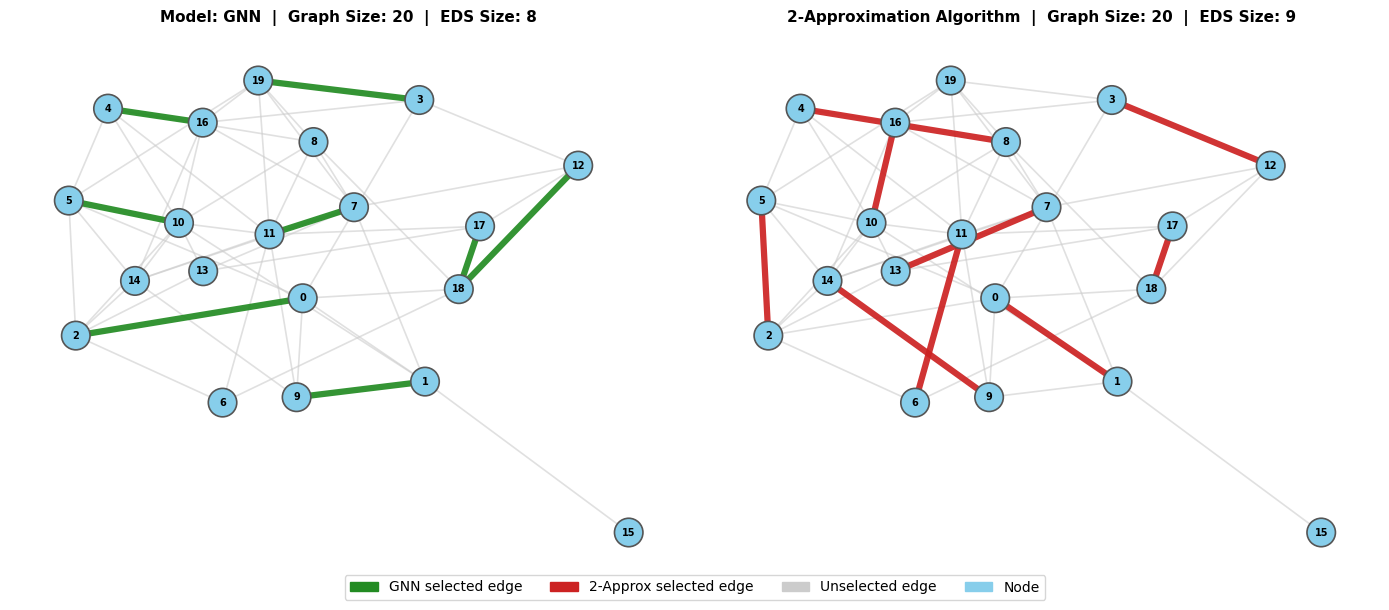

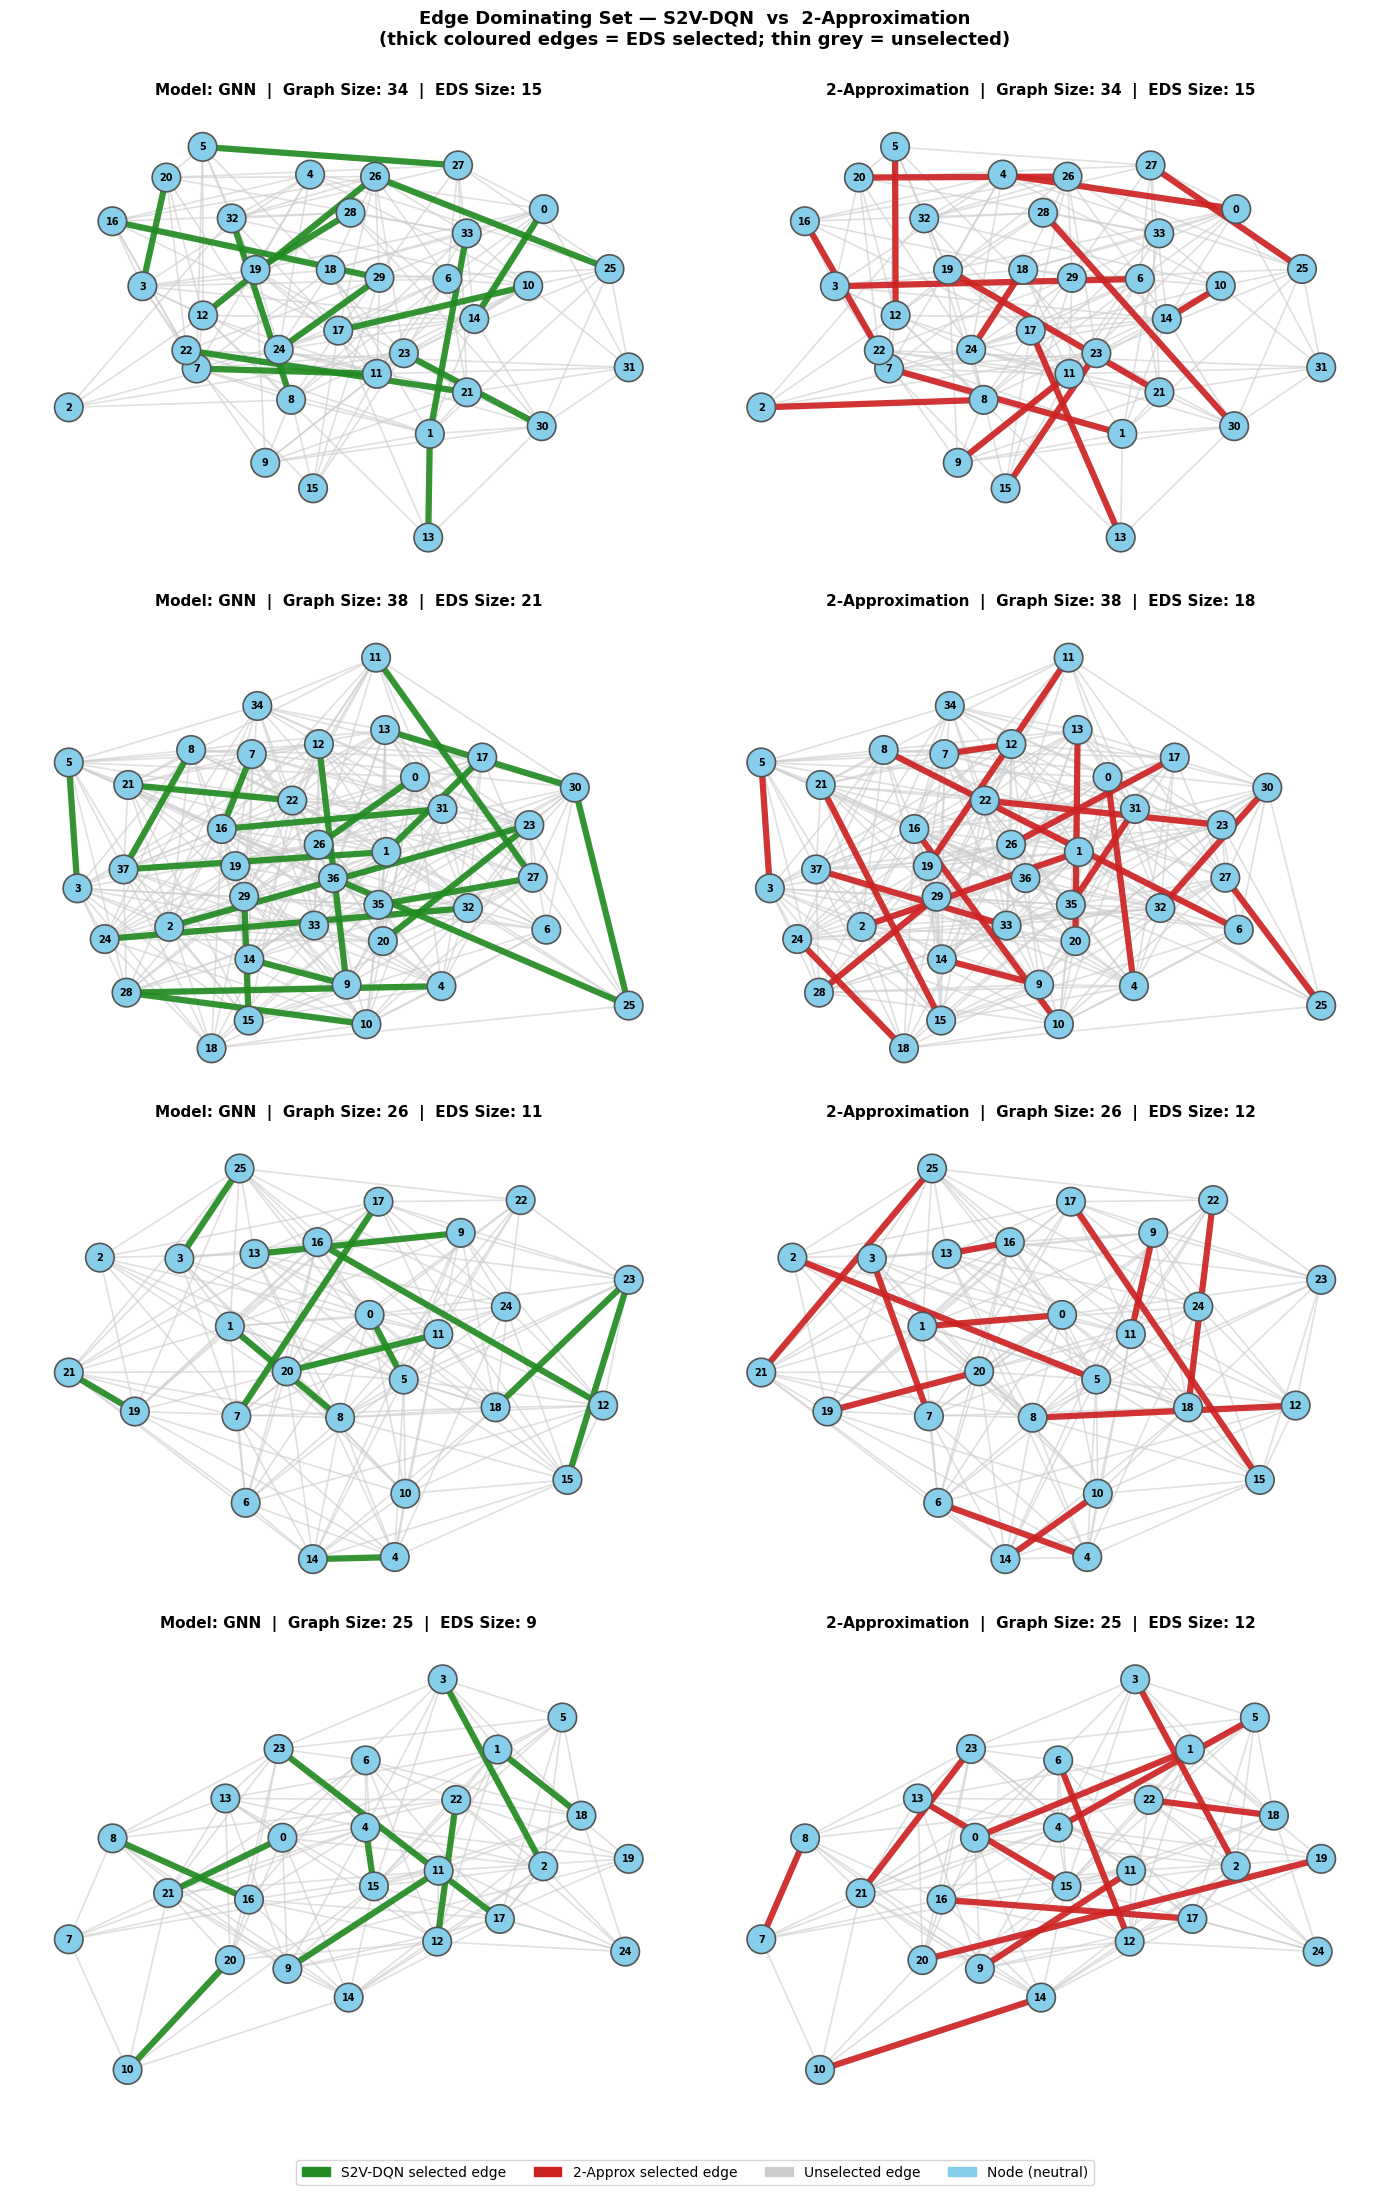

Saved → eds_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import random, torch

def run_gnn(sample):
    G, edges, covers, adj, x = (
        sample["G"], sample["edges"],
        sample["covers"], sample["adj"], sample["x"],
    )
    env = EDSEnvironment(G, edges, covers)
    st  = env.reset()
    done = False
    policy_net.eval()
    while not done:
        with torch.no_grad():
            q = policy_net(x, st, adj)
        action    = select_action(q, st, epsilon=0.0)
        st, _, done = env.step(action)
    return env.selected          


def run_two_approx(sample):
    G, edges = sample["G"], sample["edges"]
    eidx = {}
    for i, (u, v) in enumerate(edges):
        eidx[(u, v)] = i
        eidx[(v, u)] = i
    matching = nx.maximal_matching(G)  
    selected = set()
    for (u, v) in matching:
        idx = eidx.get((u, v), eidx.get((v, u), None))
        if idx is not None:
            selected.add(idx)
    return selected


def draw_eds_graph(ax, G, edges, selected_edge_idx, title,
                   selected_color, pos=None):
 
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    node_color = ["#87CEEB"] * G.number_of_nodes()   
    sel_set   = set(selected_edge_idx)
    sel_edges = [edges[i] for i in sorted(sel_set)]
    uns_edges = [edges[i] for i in range(len(edges)) if i not in sel_set]

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=uns_edges,
        edge_color="#CCCCCC",
        width=1.2,
        alpha=0.6,
    )
    if sel_edges:
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=sel_edges,
            edge_color=selected_color,
            width=4.5,
            alpha=0.92,
        )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_color,
        node_size=420,
        linewidths=1.2,
        edgecolors="#555555",
    )
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=7,
        font_color="black",
        font_weight="bold",
    )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")
    return pos


def visualize_eds_comparison(test_data, n_graphs=4, seed=0):

    rng     = random.Random(seed)
    samples = rng.sample(test_data, min(n_graphs, len(test_data)))

    fig, axes = plt.subplots(
        n_graphs, 2,
        figsize=(14, 5.5 * n_graphs),
        facecolor="white",
    )
    if n_graphs == 1:
        axes = [axes]   # keep indexing uniform

    for row, sample in enumerate(samples):
        G     = sample["G"]
        edges = sample["edges"]

        gnn_sel = run_gnn(sample)
        ap_sel  = run_two_approx(sample)

        pos = nx.spring_layout(G, seed=42)

        title_gnn = (
            f"Model: GNN  |  Graph Size: {G.number_of_nodes()}  |  "
            f"EDS Size: {len(gnn_sel)}"
        )
        title_ap = (
            f"2-Approximation  |  Graph Size: {G.number_of_nodes()}  |  "
            f"EDS Size: {len(ap_sel)}"
        )

        draw_eds_graph(
            axes[row][0], G, edges, gnn_sel,
            title_gnn, selected_color="#228B22", pos=pos,
        )
        draw_eds_graph(
            axes[row][1], G, edges, ap_sel,
            title_ap, selected_color="#CC2222", pos=pos,
        )

    legend_handles = [
        mpatches.Patch(color="#228B22", label="S2V-DQN selected edge"),
        mpatches.Patch(color="#CC2222", label="2-Approx selected edge"),
        mpatches.Patch(color="#CCCCCC", label="Unselected edge"),
        mpatches.Patch(color="#87CEEB", label="Node (neutral)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        fontsize=10,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )

    fig.suptitle(
        "Edge Dominating Set — S2V-DQN  vs  2-Approximation\n"
        "(thick coloured edges = EDS selected; thin grey = unselected)",
        fontsize=13, fontweight="bold", y=1.002,
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("eds_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → eds_comparison.png")


def visualize_single_eds(sample):
    """
    One-row, two-panel comparison for a single sample.
    Closest match to the Vertex Cover example image you provided.
    """
    G     = sample["G"]
    edges = sample["edges"]

    gnn_sel = run_gnn(sample)
    ap_sel  = run_two_approx(sample)

    pos = nx.spring_layout(G, seed=42)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")

    draw_eds_graph(
        ax1, G, edges, gnn_sel,
        f"Model: GNN  |  Graph Size: {G.number_of_nodes()}  |  EDS Size: {len(gnn_sel)}",
        selected_color="#228B22", pos=pos,
    )
    draw_eds_graph(
        ax2, G, edges, ap_sel,
        f"2-Approximation Algorithm  |  Graph Size: {G.number_of_nodes()}  |  EDS Size: {len(ap_sel)}",
        selected_color="#CC2222", pos=pos,
    )

    legend_handles = [
        mpatches.Patch(color="#228B22", label="GNN selected edge"),
        mpatches.Patch(color="#CC2222", label="2-Approx selected edge"),
        mpatches.Patch(color="#CCCCCC", label="Unselected edge"),
        mpatches.Patch(color="#87CEEB", label="Node"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=4,
        fontsize=10, frameon=True,
        bbox_to_anchor=(0.5, -0.02),
    )
    plt.tight_layout()
    plt.show()

visualize_single_eds(test_data[0])
visualize_eds_comparison(test_data, n_graphs=4, seed=0)
